Deep learning models, especially deep convolutional neural networks (CNNs), have shown remarkable performance in image classification, object detection, and other computer vision tasks. However, training these models effectively requires large amounts of labeled data and efficient optimization techniques. Two of the most critical techniques used to improve model performance and generalization are Data Augmentation and __Regularization.__


__Data Augmentation__ artificially expands the training dataset by applying transformations such as cropping, flipping, rotating, and adding noise to images. This helps models generalize better to unseen data by reducing overfitting.

__Regularization__ techniques prevent models from memorizing training data by imposing constraints on model complexity. Methods like __Weight Decay, Dropout, Batch Normalization, Gradient Clipping, and Learning Rate Scheduling__ play crucial roles in ensuring stable and efficient training.

In this chapter, we will explore how __Data Augmentation and Regularization__ can be applied to train a __state-of-the-art (SOTA) model in under five minutes__, achieving over __90% accuracy__ on the __CIFAR-10__ dataset using __PyTorch__.

In [1]:
import os
import torch
import torchvision
import tarfile
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
from torchvision.datasets.utils import download_url
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torchvision.transforms as tt # pytorch built in function for data augmentation
from torchvision.utils import make_grid
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

matplotlib.rcParams['figure.facecolor'] = '#ffffff'

C:\Users\Prasad\anaconda3\Lib\site-packages\triton\knobs.py:212: UserWarning: Failed to find cuobjdump.exe
  warnings.warn(f"Failed to find {binary}")
C:\Users\Prasad\anaconda3\Lib\site-packages\triton\knobs.py:212: UserWarning: Failed to find nvdisasm.exe
  warnings.warn(f"Failed to find {binary}")


In [2]:
data_dir = './data/cifar10'
print(os.listdir(data_dir))
classes = os.listdir(data_dir + "/train")
print(classes)

['test', 'train']
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


What is Data Augmentation?
Data augmentation artificially increases the size and diversity of a dataset by applying random transformations. This prevents the model from relying too much on specific features in the training data, thus improving generalization.


Common Data Augmentation Techniques

Technique	          =>                              Description

Random               =>       Cropping	Randomly selects a smaller region of the image.

Horizontal Flipping	   =>                     Flips images left-to-right.

Rotation	              =>      Rotates images within a certain degree range.

Color Jittering	           =>   Randomly changes brightness, contrast, and saturation.

Gaussian Noise	       =>     Adds random noise to the image to make training more robust.

# pytorch provides a built in funvtion for data augmentation torchvision.transforms:

In [3]:
stats = ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
train_tfms = tt.Compose([tt.RandomCrop(32, padding=4, padding_mode='reflect'),
                        tt.RandomHorizontalFlip(),
                         # tt.RandomRotate,
                         # tt.RandomResizedCrop(256, scale=(0.5,0.9), ratio=(1,1)),
                         #tt.ColorJitter(brightness=0.1,contrast=0.1, saturation=0.1, hue=0.1),
                         tt.ToTensor(),
                         tt.Normalize(*stats,inplace=True)
                        ])

valid_tfms = tt.Compose([tt.ToTensor(), tt.Normalize(*stats)])

In [4]:
# Pytorch Dataset

train_ds = ImageFolder(data_dir+'/train', train_tfms)
valid_ds = ImageFolder(data_dir+'/test', valid_tfms)

In [5]:
batch_size = 400

train_dl = DataLoader(train_ds, batch_size, shuffle=True, num_workers=3, pin_memory=True)

valid_dl = DataLoader(valid_ds, batch_size*2, num_workers=3, pin_memory=True)

Let's take a look at some sample images from the training dataloader. To display the images, we'll need to denormalize the pixels values to bring them back into the range (0,1).

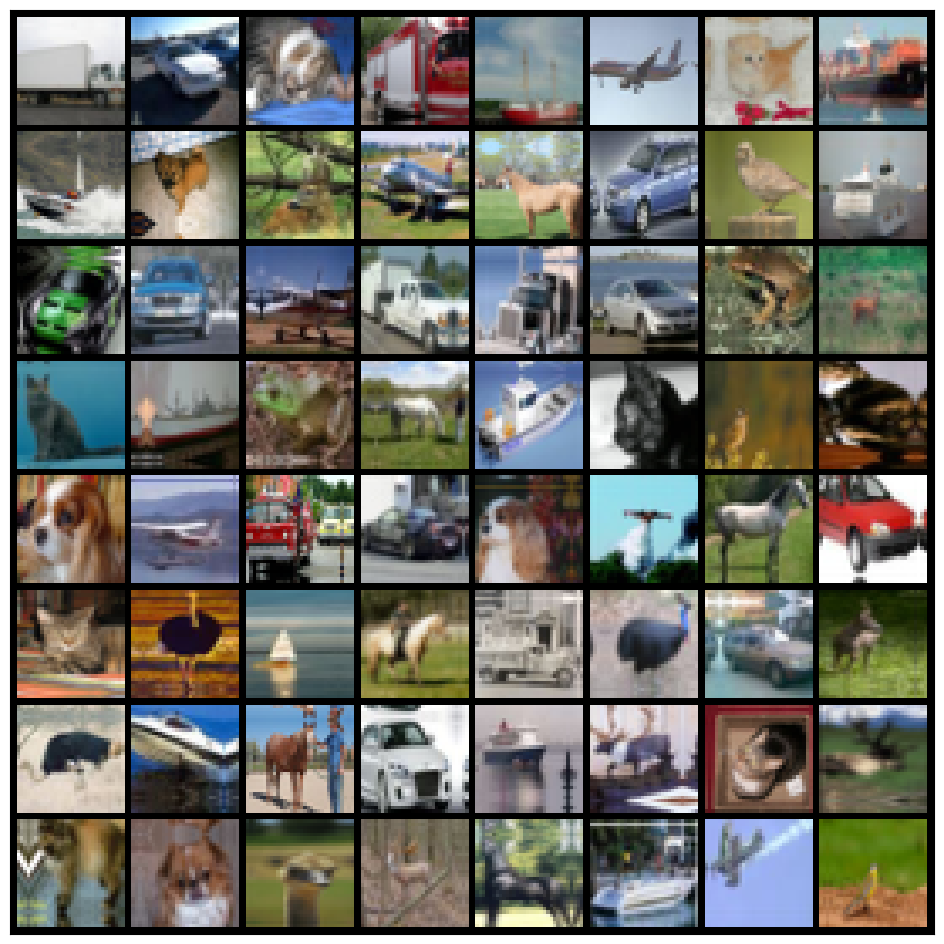

In [6]:
def denormalize(images, means, stds):
    means = torch.tensor(means).reshape(1, 3, 1, 1)
    stds = torch.tensor(stds).reshape(1, 3, 1, 1)
    return images * stds + means


def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(12, 12))
        ax.set_xticks([]); ax.set_yticks([])
        denorm_images = denormalize(images, * stats)
        ax.imshow(make_grid(denorm_images[:64], nrow=8).permute(1, 2, 0).clamp(0,1))
        break


show_batch(train_dl)
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..1.0].


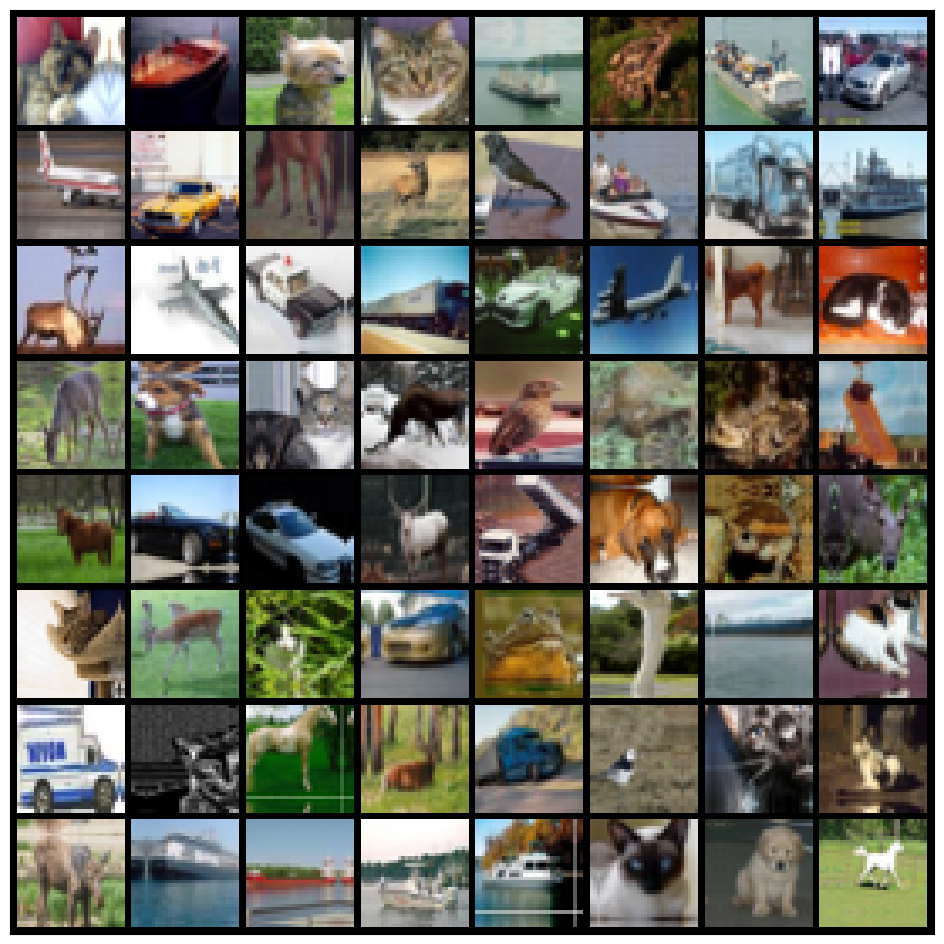

In [7]:
def denormalize(images, means, stds):
    means = torch.tensor(means).reshape(1, 3, 1, 1)
    stds = torch.tensor(stds).reshape(1, 3, 1, 1)
    return images * stds + means


def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(12, 12))
        ax.set_xticks([]); ax.set_yticks([])
        denorm_images = denormalize(images, * stats)
        ax.imshow(make_grid(denorm_images[:64], nrow=8).permute(1, 2, 0))
        break


show_batch(train_dl)
plt.show()

To understand why we do this, think of it like translating a language between two people who speak different dialects: the Neural Network and your Computer Screen.
# 1. The Logic of "Normalizing" (The Model's Perspective)
Neural networks are like high-performance engines; they work best when the fuel (data) is consistent.
* The Problem: Raw image pixels are usually integers from 0 to 255. For a mathematical model, these are "huge" and vary wildly.
* The Solution: We Standardize them. We subtract the average (Mean) and divide by the spread (Std).
* The Result: The data now centers around 0. This makes the math inside the network stable and fast.
__Analogy: If you are comparing people's heights, it’s easier to say "2cm above average" or "1cm below average" rather than saying "178cm" and "175cm."__
# 2. The Logic of "Denormalizing" (The Human's Perspective)
When you want to see the image, you have a problem. Your computer screen doesn't understand "0.5 above average." It only knows:
* 0.0 = Black
* 1.0 = White (or 255 for integers)
The Denormalize formula (
) is simply the "Undo" button. It translates the model's specialized math back into the "language" of light and color that humans can see.
# 3. The Logic of ".clamp()" (The Final Polish)
Even after you "undo" the math, you run into Floating Point Noise.
Because computers are not infinitely precise at math, 
 often equals 
. In your image math, a pixel that was supposed to be a perfect 0.0 (Black) might end up being -0.0000000001.
* The Screen's Reaction: "I don't know how to show a color darker than black!"
* The Warning: matplotlib sees that tiny negative number and panics, giving you that long error message.
* The Clamp: It's the "safety rail." It says: "If the math resulted in anything slightly less than 0, just call it 0. If it's slightly over 1, just call it 1."



| Step | Action | Values (Approx) | Why? |
|:---|:---|:---|:---|
| **1. Raw Data** | Load Image | `0` to `255` | How files are stored. |
| **2. Preprocess** | Normalize | `-2.0` to `2.0` | Helps the AI learn better. |
| **3. Training** | Model Logic | `-5.0` to `5.0` | The AI doing its "thinking." |
| **4. Visualize** | Denormalize | `-0.00001` to `1.00001` | Moving back to human scale. |
| **5. Clamp** | `.clamp(0, 1)` | `0.0` to `1.0` | Cleaning up tiny math errors. |
| **6. Result** | `plt.imshow` | `Pure RGB` | A clean, beautiful image. |


Summary
* Normalization is for the Machine.
* Denormalization is for the Human.
* Clamping is for the Computer's math limitations.



In [9]:
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data, device):
    """Move tensor(s) to choosen device"""
    if isinstance(data, (list, tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)


class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device
    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        """Number of self batches"""
        return len(self.dl)

In [10]:
device = get_default_device()
device

device(type='cuda')

In [11]:
train_dl = DeviceDataLoader(train_dl, device)
valid_dl = DeviceDataLoader(valid_dl, device)

In [12]:
train_dl

In [13]:
valid_dl


| Concept | Manual Way (Non-Native) | Dunder Way (Native) |
| :--- | :--- | :--- |
| Accessing Data | my_obj.get_batch_and_move_to_gpu(0) | for batch in my_obj: |
| Checking Size | my_obj.calculate_total_batches() | len(my_obj) |
| Feel | Clunky, custom, hard to read. | Natural, clean, "Pythonic." |

🚀 Deep Dive: GPU Acceleration & Pythonic Data Loading
In this section, we implement a system to automatically move our data to the GPU (CUDA) during training. This involves two main concepts: Device Agnosticism and Pythonic Abstraction via Dunder methods.

🛠️ Part 1: Device Management Logic
To ensure our code is portable, we avoid hardcoding cuda. We detect the hardware dynamically.
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    return torch.device('cpu')

def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list, tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

Why this matters:

Recursive Moving: to_device handles nested lists or tuples, ensuring every single tensor in a batch is moved.

Non-Blocking: Using non_blocking=True allows the CPU to keep working while the data is being uploaded to the GPU, reducing bottlenecks.

🧠 Part 2: Understanding "Dunder" Methods
Dunder (Double Underscore) methods are the "hooks" that connect custom classes to Python’s built-in features.

1. From "Static Box" to "Active Tool"
Without these methods, our class would be a Static Box—Python wouldn't know how to loop over it or measure it. By adding them, we create an Active Tool that mimics native Python objects (like lists).

Concept,Manual Way (Non-Native),Dunder Way (Native/Pythonic)
Accessing Data,my_obj.get_batch_and_move_to_gpu(),for batch in my_obj:
Checking Size,my_obj.calculate_total_batches(),len(my_obj)
Initialization,"my_obj.setup_variables(dl, dev)","my_obj = DeviceDataLoader(dl, dev)"
Code Feel,"Clunky, custom, and hard to read.","Natural, clean, and professional."

🏗️ Part 3: The DeviceDataLoader Implementation
This class wraps our existing DataLoader to make the GPU transfer "invisible" to our training loop.

This is the heart of Object-Oriented Programming (OOP) in Python. To understand this logically, we have to look at the difference between a Data Container and an Active Tool.

1. The "Static Box" (Without Dunders)
Imagine you created a class called MyBox and put a list of 1,000 images inside it.

If you don't use Dunder methods, Python treats MyBox as a "black box." It knows the box exists, but it doesn't know how to look inside it.

If you try to loop over it: for x in MyBox:, Python says: "TypeError: 'MyBox' object is not iterable."

If you try to check its size: len(MyBox), Python says: "TypeError: object of type 'MyBox' has no len()."

In this state, your DeviceDataLoader would be useless for training because PyTorch's training loops expect something that "acts" like a list.

2. The "Active Tool" (With Dunders)
By adding __iter__ and __len__, you are teaching Python how to interact with your custom object using its built-in syntax.

The Logic of __len__: You are telling Python, "Whenever you see the len() function used on me, don't panic. Just go into my basement, find the real data loader self.dl, and tell me its size."

The Logic of __iter__: You are telling Python, "Whenever you see a for loop, I am an Iterable. Start a process where I fetch a batch, move it to the GPU, and hand it to the loop."

3. The "Native" Behavior
The goal of your code is to make DeviceDataLoader feel invisible.

Because of these Dunders, you can swap a standard PyTorch DataLoader with your custom DeviceDataLoader, and the rest of your code won't even notice the difference. 
| Concept | Manual Way (Non-Native) | Dunder Way (Native) |
| :--- | :--- | :--- |
| Accessing Data | my_obj.get_batch_and_move_to_gpu(0) | for batch in my_obj: |
| Checking Size | my_obj.calculate_total_batches() | len(my_obj) |
| Feel | Clunky, custom, hard to read. | Natural, clean, "Pythonic." |

Summary of the Logic
Without Dunders, your class is just Data.
With Dunders, your class is Behavior.

It allows you to hide the "ugly" parts (like moving 500MB of images to a GPU) behind a simple, beautiful for loop.

Markdown for your Notebook
You can add this "Deep Dive" section to your notes to explain why we use these specific methods:

Markdown
### 🧠 Why use Dunder Methods?

In Python, **Dunder (Double Underscore)** methods allow our custom classes to "mimic" built-in objects. 

1. **Protocol Implementation**: By defining `__iter__`, our class follows the **Iteration Protocol**. This turns our class from a static container into a dynamic stream of data.
2. **Abstraction**: We hide the complexity of GPU memory management. The training loop doesn't "know" it's moving data to CUDA; it just thinks it's reading a list.
3. **Consistency**: It allows us to use standard Python functions like `len()` and `next()` on our custom objects, making the code easier for others to read and maintain.

In [14]:
class SimpleResidualBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()

    def forward(self, x):
        out = self.conv1(x)
        out = self.relu1(out)
        out = self.conv2(out)
        return self.relu2(out) + x
        
 

In [15]:
simple_resnet = to_device(SimpleResidualBlock(), device)

for images, labels in train_dl:
    out = simple_resnet(images)
    print(out.shape)
    break

del simple_resnet, images, labels
torch.cuda.empty_cache()

torch.Size([400, 3, 32, 32])


In [22]:
def accuracy(outputs, labels):
    _,preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))


class ImageClassificationBase(nn.Module):
    def training_step(self, batch):
        images, labels = batch
        out = self(images)
        loss = F.cross_entropy(out, labels)
        return loss

    def validation_step(self, batch):
        images, labels  = batch
        out = self(images)
        loss = F.cross_entropy(out, labels)
        acc = accuracy(out, labels)
        return {'val_loss': loss.detach(), 'val_acc':acc}

    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()
        return {'val_loss': epoch_loss.item(), 'val_acc':epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print("Epoch [{}], last_lr: {:.5f}, train_loss: {:.4f}, val_loss:{:.4f}, val_acc: {:.4f}".format(
            epoch, result['lrs'][-1], result['train_loss'], result['val_loss'], result['val_acc']
        ))

    @torch.no_grad()
    def evaluate(self, val_loader):
        self.eval()
        outputs = [self.validation_step(batch) for batch in val_loader]
        return self.validation_epoch_end(outputs)
        

In [24]:
def conv_block(in_channels, out_channels, pool=False):
    layers = [nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
             nn.BatchNorm2d(out_channels),
             nn.ReLU(inplace=True)]
    if pool: layers.append(nn.MaxPool2d(2))
    return nn.Sequential (*layers)


class ResNet9(ImageClassificationBase):
    def __init__(self, in_channels, num_classes):
        super().__init__()

        self.conv1 = conv_block(in_channels, 64)
        self.conv2 = conv_block(64, 128, pool=True)
        self.res1 = nn.Sequential(conv_block(128, 128), conv_block(128, 128))
        self.conv3 = conv_block(128, 256, pool=True)
        self.conv4 = conv_block(256, 512, pool=True)
        self.res2 = nn.Sequential(conv_block(512, 512), conv_block(512, 512))
        self.classifier = nn.Sequential(nn.MaxPool2d(4), 
                                       nn.Flatten(),
                                       nn.Dropout(0.2),
                                       nn.Linear(512, num_classes))

    def forward(self, xb):
        out = self.conv1(xb)
        out = self.conv2(out)
        out = self.res1(out) + out
        out = self.conv3(out)
        out = self.conv4(out)
        out = self.res2(out) + out
        out = self.classifier(out)
        return out

In [25]:
model = to_device(ResNet9(3, 10), device)
model

ResNet9(
  (conv1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (conv2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (res1): Sequential(
    (0): Sequential(
      (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=Tr

# LR Scheduling, Weight Decay and Gradient Clipping

In [30]:
def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']

def fit_one_cycle(epochs, max_lr, model, train_loader, val_loader, weight_decay=0, grad_clip=None,
                 opt_func = torch.optim.SGD):
    torch.cuda.empty_cache()
    history = []

    # Set up custom optimizer with weight decay
    optimizer = opt_func(model.parameters(), max_lr, weight_decay = weight_decay)
    # Set up one-cycle learning rate scheduler
    sched = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr, epochs=epochs,
                                               steps_per_epoch=len(train_loader))
    for epoch in range(epochs):
        # Training Phase
        model.train()
        train_losses = []
        lrs = []
        for batch in train_loader:
            loss = model.training_step(batch)
            train_losses.append(loss)
            loss.backward()

            # Gradient CLipping
            if grad_clip:
                nn.utils.clip_grad_value_(model.parameters(), grad_clip)

            optimizer.step()
            optimizer.zero_grad()

            # Record & update learning rate
            lrs.append(get_lr(optimizer))
            sched.step()

        # Validation phase
        result = model.evaluate(val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        result['lrs'] = lrs
        model.epoch_end(epoch, result)
        history.append(result)

    return history

In [27]:
history = [model.evaluate(valid_dl)]
history

[{'val_loss': 2.3091185092926025, 'val_acc': 0.09884615987539291}]

In [28]:
epochs = 8
max_lr = 0.01
grad_clip = 0.1
weight_decay = 1e-4
opt_func = torch.optim.Adam

In [31]:
%%time
history += fit_one_cycle(epochs, max_lr, model, train_dl, valid_dl, 
                        grad_clip=grad_clip,
                        weight_decay=weight_decay, 
                        opt_func = opt_func)

Epoch [0], last_lr: 0.00393, train_loss: 1.5435, val_loss:1.4614, val_acc: 0.5257
Epoch [1], last_lr: 0.00935, train_loss: 1.1068, val_loss:1.3780, val_acc: 0.5737
Epoch [2], last_lr: 0.00972, train_loss: 0.8800, val_loss:0.8014, val_acc: 0.7134
Epoch [3], last_lr: 0.00812, train_loss: 0.6493, val_loss:0.5828, val_acc: 0.8000
Epoch [4], last_lr: 0.00556, train_loss: 0.5155, val_loss:0.5251, val_acc: 0.8203
Epoch [5], last_lr: 0.00283, train_loss: 0.4041, val_loss:0.5257, val_acc: 0.8217
Epoch [6], last_lr: 0.00077, train_loss: 0.3031, val_loss:0.3208, val_acc: 0.8906
Epoch [7], last_lr: 0.00000, train_loss: 0.2307, val_loss:0.2935, val_acc: 0.9021
CPU times: total: 32 s
Wall time: 5min 59s


In [36]:
def plot_accuracies(history):
    accuracies = [x['val_acc'] for x in history]
    plt.plot(accuracies, '-x')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('Accuracy vs. No. of epochs')



In [42]:
def plot_losses(history):
    train_losses = [x.get('train_loss') for x in history]
    val_losses = [x['val_loss'] for x in history]
    plt.plot(train_losses, '-bx')
    plt.plot(val_losses, '-rx')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend(['Training', 'Validation'])
    plt.title('Loss vs. No. of epochs');
    

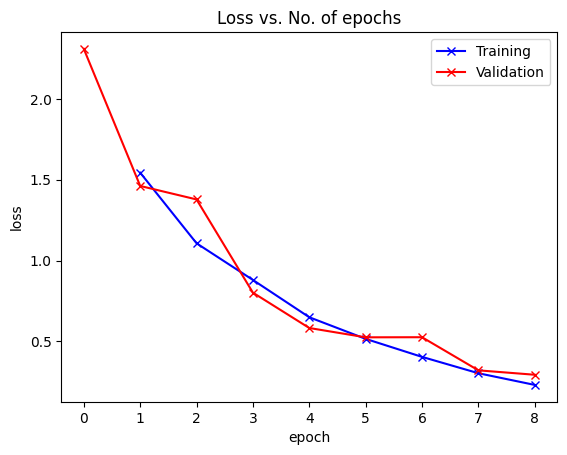

In [43]:
plot_losses(history)
plt.show()

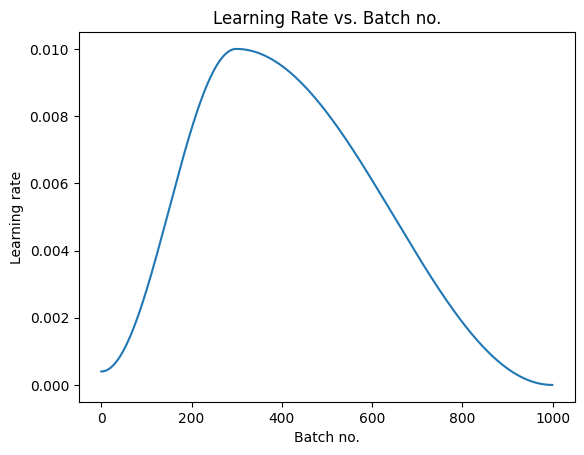

In [44]:
def plot_lrs(history):
    lrs = np.concatenate([x.get('lrs', []) for x in history])
    plt.plot(lrs)
    plt.xlabel('Batch no.')
    plt.ylabel('Learning rate')
    plt.title('Learning Rate vs. Batch no.');

plot_lrs(history)
plt.show()

In [45]:
def predict_image(img, model):
    # Convert to a batch of 1
    xb = to_device(img.unsqueeze(0), device)
    # Get predictions from model
    yb = model(xb)
    # Pick index with highest probability
    _, preds  = torch.max(yb, dim=1)
    # Retrieve the class label
    return train_ds.classes[preds[0].item()]

Label: airplane , Predicted: airplane


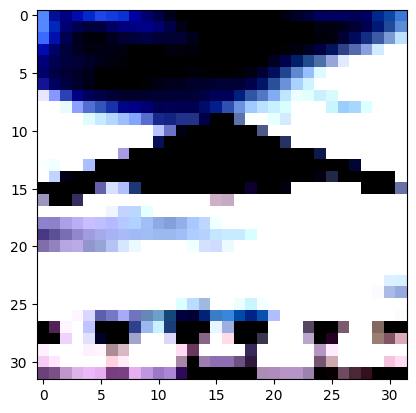

In [47]:
img, label = valid_ds[10]
plt.imshow(img.permute(1, 2, 0).clamp(0, 1))
print('Label:', train_ds.classes[label], ', Predicted:', predict_image(img, model))
plt.show()

Label: automobile , Predicted: automobile


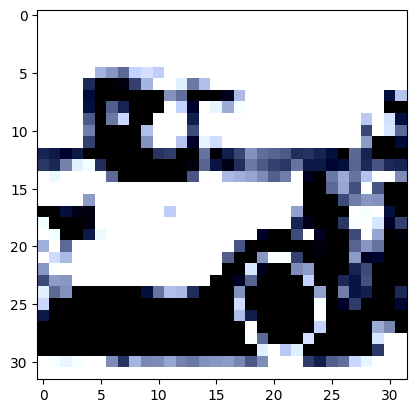

In [49]:
img, label = valid_ds[1002]
plt.imshow(img.permute(1, 2, 0).clip(0,1))
print('Label:', valid_ds.classes[label], ', Predicted:', predict_image(img, model))
plt.show()

Label: frog , Predicted: deer


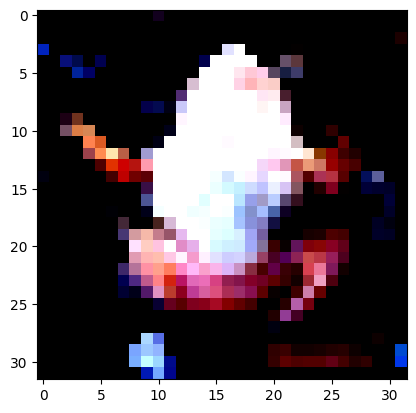

In [52]:
img, label = valid_ds[6130]
plt.imshow(img.permute(1, 2, 0).clip(0,1))
    
print('Label:', train_ds.classes[label], ', Predicted:', predict_image(img, model))
plt.show()

In [53]:
torch.save(model.state_dict(), 'cifar10-resnet9.pth')

* Why do we normalize images before training deep learning models?
* What are the benefits of using data augmentation?
* How do residual connections help deep networks?
* What is the main advantage of batch normalization?
* How does weight decay prevent overfitting?
* What is gradient clipping, and why is it useful?
* Why is learning rate scheduling important?
* How does the Adam optimizer differ from SGD?
* Can a model trained with data augmentation generalize better than one without? Why?
* What is the impact of using dropout during training?